# Targeted Social Prescription (Social-prescribing-inspired)
## Notebook 1: Data preprocessing & cohort construction (RAND HRS 1992–2022)

This notebook:
1) loads RAND HRS longitudinal data (1992–2022);
2) reshapes wave-specific variables into a long panel format (`hhidpn` × `wave`);
3) constructs a baseline cohort (Age ≥ 65) and a transparent, rule-based `high_risk` flag;
4) defines a next-wave hospitalisation outcome (`next_hosp`) via shift.

Key fix included:
- **Gender is time-invariant** and is derived from RAND `ragender` (preferred) to avoid wave-specific missingness.


## 1. Data Source Description

This study uses the RAND HRS Longitudinal File (1992–2022).

The RAND file harmonizes wave-specific variables from the Health and Retirement Study (HRS) into a consistent longitudinal structure.

Key domains used in this project include:
- Demographics (age, gender)
- Functional limitations (ADL/IADL)
- Mental health (CES-D)
- Healthcare utilisation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_RAW = os.path.join("..", "data_raw")
DATA_PROCESSED = os.path.join("..", "data_processed")
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

DTA_PATH = os.path.join(DATA_RAW, "randhrs1992_2022v1.dta")
assert os.path.exists(DTA_PATH), f"Cannot find file: {DTA_PATH}"
print("Found:", DTA_PATH)

Found: ..\data_raw\randhrs1992_2022v1.dta


In [3]:
WAVES = list(range(1, 17))

BASE_COLS = ["hhidpn", "ragender", "raedyrs"]

AGE_COLS  = [f"r{w}agey_e" for w in WAVES]
HOSP_COLS = [f"r{w}hosp"   for w in WAVES]
DIAB_COLS = [f"r{w}diab"   for w in WAVES]
CESD_COLS = [f"r{w}cesd"   for w in range(2, 17)]  # wave1 通常没有 r1cesd
ADL_COLS  = ["r1adlw"] + [f"r{w}adl5a" for w in range(2, 17)]  # wave1 用 r1adlw

USE_COLS = BASE_COLS + AGE_COLS + HOSP_COLS + DIAB_COLS + CESD_COLS + ADL_COLS
print("Total columns:", len(USE_COLS))

Total columns: 82


In [4]:
CHUNKSIZE = 20000  # 内存小就调小

reader = pd.read_stata(
    DTA_PATH,
    columns=USE_COLS,
    chunksize=CHUNKSIZE,
    convert_categoricals=False
)
print("Reader ready.")

Reader ready.


In [5]:
import os
import pandas as pd

# 你项目里 randhrs 的 dta 路径（你截图里是在 data_raw 下）
DTA_PATH = os.path.join("..", "data_raw", "randhrs1992_2022v1.dta")

# 读入 STATA
wide = pd.read_stata(DTA_PATH, convert_categoricals=False)

# 统一列名为小写（后面匹配 r1agey_e / ragender 才稳定）
wide.columns = wide.columns.astype(str).str.lower()

print("Loaded wide:", wide.shape)
print("Example cols:", list(wide.columns)[:20])

Loaded wide: (45234, 19880)
Example cols: ['hhidpn', 's1hhidpn', 'r1mstat', 'r1mpart', 's1bmonth', 's1byear', 's1bdate', 's1bflag', 's1cohbyr', 's1hrsamp', 's1ahdsmp', 's1dmonth', 's1dyear', 's1ddate', 's1dsrc', 's1dtimtdth', 's1dage_y', 's1dage_m', 's1racem', 's1hispan']


In [6]:
# ---------------------------------------------
# 3) Build long panel from RAND wide (numeric waves)
# ---------------------------------------------
import re
import pandas as pd

# 0) auto-pick the wide dataframe (prefer `wide`)
W = None
for name in ["wide", "W", "df_wide", "rand", "df", "data"]:
    if name in globals() and hasattr(globals()[name], "columns"):
        W = globals()[name]
        print(f"Using wide dataframe variable: {name}, shape={W.shape}")
        break

if W is None:
    raise NameError("Cannot find the wide dataframe. Expected one of: wide / W / df_wide / rand / df / data")

# make sure column names are strings + lower
W = W.copy()
W.columns = W.columns.astype(str).str.lower()

# 1) detect age columns like r1agey_e, r2agey_e, ...
age_cols = [c for c in W.columns if re.match(r"^r\d+agey_e$", c)]
print("Detected age columns (first 20):", age_cols[:20])
print("Num waves detected:", len(age_cols))

if len(age_cols) == 0:
    # fallback diagnostic
    maybe = [c for c in W.columns if "agey" in c or "age" in c]
    print("Fallback age-like columns (first 50):", maybe[:50])
    raise ValueError("No r{wave}agey_e columns found. Check RAND column naming.")

# 2) build panel rows per wave
panel_list = []
for age_col in age_cols:
    wave = int(re.findall(r"\d+", age_col)[0])  # r{wave}agey_e -> wave
    tmp = pd.DataFrame({
        "hhidpn": W["hhidpn"],
        "wave": wave,
        "age": pd.to_numeric(W[age_col], errors="coerce"),
    })

    # gender: use ragender if exists (RAND)
    if "ragender" in W.columns:
        tmp["gender"] = pd.to_numeric(W["ragender"], errors="coerce")
    elif "gender" in W.columns:
        tmp["gender"] = pd.to_numeric(W["gender"], errors="coerce")
    else:
        tmp["gender"] = pd.NA

    # edu: use raeduc if exists, else edu_years if you already created it
    if "raeduc" in W.columns:
        tmp["edu_years"] = pd.to_numeric(W["raeduc"], errors="coerce")
    elif "edu_years" in W.columns:
        tmp["edu_years"] = pd.to_numeric(W["edu_years"], errors="coerce")
    else:
        tmp["edu_years"] = pd.NA

    # wave-specific vars (if exist)
    var_map = {
        "diabetes": f"r{wave}diab",
        "adl_any":  f"r{wave}adl5a",   # ✅ 关键：用 adl5a
        "cesd":     f"r{wave}cesd",
        "hosp":     f"r{wave}hosp",
    }

    for new_var, wide_var in var_map.items():
        if wide_var in W.columns:
            v = pd.to_numeric(W[wide_var], errors="coerce")

            if new_var == "adl_any":
                tmp[new_var] = (v > 0).astype("Int64")
            else:
                tmp[new_var] = v
        else:
            tmp[new_var] = pd.NA

    if wave == "10":  # 随便挑一个你有的 wave
        print("check adl col:", f"r{wave}adl5a" in W.columns)

    panel_list.append(tmp)

# 3) concat + clean
panel = pd.concat(panel_list, ignore_index=True)
panel = panel.dropna(subset=["age"])
panel = panel.sort_values(["hhidpn", "wave"])

print("Panel shape:", panel.shape)
print("Gender distribution (panel):")
print(panel["gender"].value_counts(dropna=False).sort_index())
print("Wave distribution (top):")
print(panel["wave"].value_counts().sort_index().head(10))

Using wide dataframe variable: wide, shape=(45234, 19880)
Detected age columns (first 20): ['r1agey_e', 'r2agey_e', 'r3agey_e', 'r4agey_e', 'r5agey_e', 'r6agey_e', 'r7agey_e', 'r8agey_e', 'r9agey_e', 'r10agey_e', 'r11agey_e', 'r12agey_e', 'r13agey_e', 'r14agey_e', 'r15agey_e', 'r16agey_e']
Num waves detected: 16
Panel shape: (296197, 9)
Gender distribution (panel):
gender
1    123056
2    173141
Name: count, dtype: int64
Wave distribution (top):
wave
1     12651
2     19641
3     17991
4     21384
5     19578
6     18165
7     20129
8     18469
9     17217
10    22034
Name: count, dtype: int64


## 2. Study Population & Baseline Definition

The analytic cohort includes respondents aged 65 years or older.

We:
- Restrict the panel to age ≥ 65
- Remove individuals with missing gender
- Sort observations by respondent ID and wave
- Define baseline as the most recent eligible observation per individual

In [7]:
eligible = panel[(panel["age"] >= 65) & (panel["gender"].notna())].copy()
eligible = eligible.sort_values(["hhidpn", "wave"])
baseline = eligible.groupby("hhidpn", as_index=False).tail(1).copy()

print("Baseline unique persons:", baseline["hhidpn"].nunique())
print("Baseline wave distribution:")
print(baseline["wave"].value_counts().sort_index())


Baseline unique persons: 29371
Baseline wave distribution:
wave
1       49
2     1121
3     1242
4     1385
5     1439
6     1249
7     1250
8     1289
9     1568
10    1227
11    1437
12    1723
13    1756
14    1503
15    2129
16    9004
Name: count, dtype: int64


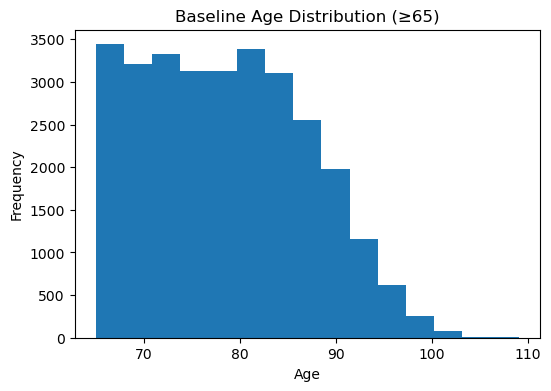

In [8]:
plt.figure(figsize=(6,4))
plt.hist(baseline['age'], bins=15)
plt.title("Baseline Age Distribution (≥65)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

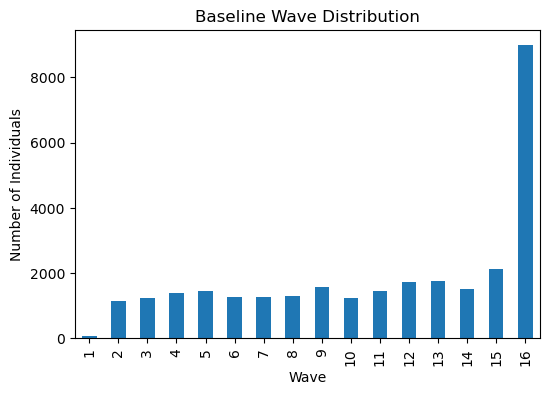

In [9]:
plt.figure(figsize=(6,4))
baseline['wave'].value_counts().sort_index().plot(kind='bar')
plt.title("Baseline Wave Distribution")
plt.xlabel("Wave")
plt.ylabel("Number of Individuals")
plt.show()

## 3. Missing Data Pattern

Missingness arises from:
- Wave-specific questions
- Skip patterns
- Attrition across follow-up waves

No imputation was performed at this stage.

In [10]:
# Missingness (baseline) - safe version
need = ["age", "gender", "edu_years", "diabetes", "adl_any", "cesd", "hosp"]
have = [c for c in need if c in baseline.columns]
missing_cols = [c for c in need if c not in baseline.columns]

print("\nMissingness (baseline):")
print("Columns found:", have)
print("Columns NOT found:", missing_cols)

print(baseline[have].isna().mean().sort_values(ascending=False))



Missingness (baseline):
Columns found: ['age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp']
Columns NOT found: []
cesd         0.186715
hosp         0.011202
diabetes     0.002451
adl_any      0.001668
edu_years    0.000306
gender       0.000000
age          0.000000
dtype: float64


In [11]:
baseline.head()

,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp
180937,2010,5,65.0,2,1.0,0.0,0,1.0,0.0
452342,3010,11,76.0,1,3.0,0.0,0,0.0,1.0
497577,3020,12,75.0,2,5.0,0.0,0,0.0,1.0
678514,10001010,16,83.0,1,3.0,0.0,0,1.0,0.0
678516,10003030,16,66.0,2,5.0,0.0,0,2.0,0.0


**Note**: RAND HRS uses an 8-item CESD scale (original CESD has 20 items). Research indicates that an 8-item CESD score ≥ 4 is equivalent to original CESD ≥ 16, representing a reasonable threshold for clinically significant depressive symptoms (Steffick, 2000).

In [12]:
baseline = baseline.copy()

# --- 1️⃣ CESD >= 4 ---
if "cesd" in baseline.columns:
    baseline["cesd_ge4"] = (baseline["cesd"].fillna(-999) >= 4).astype(int)
else:
    baseline["cesd_ge4"] = 0

# --- 2️⃣ Ensure adl_any exists ---
if "adl_any" not in baseline.columns:
    baseline["adl_any"] = 0

# --- 3️⃣ Ensure diabetes exists ---
if "diabetes" not in baseline.columns:
    baseline["diabetes"] = 0

# --- 4️⃣ High risk definition ---
baseline["high_risk"] = (
    (baseline["diabetes"] >= 1) |
    (baseline["adl_any"] >= 1) |
    (baseline["cesd_ge4"] >= 1)
).astype(int)

# --- 5️⃣ Safe column selection ---
need_cols = [
    "hhidpn","wave","age","gender","edu_years",
    "diabetes","adl_any","cesd","hosp",
    "high_risk"
]

have_cols = [c for c in need_cols if c in baseline.columns]
missing_cols = [c for c in need_cols if c not in baseline.columns]

print("Columns exported:", have_cols)
print("Columns missing:", missing_cols)

baseline_out = baseline[have_cols].copy()

baseline_out.head()

Columns exported: ['hhidpn', 'wave', 'age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk']
Columns missing: []


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
180937,2010,5,65.0,2,1.0,0.0,0,1.0,0.0,0
452342,3010,11,76.0,1,3.0,0.0,0,0.0,1.0,0
497577,3020,12,75.0,2,5.0,0.0,0,0.0,1.0,0
678514,10001010,16,83.0,1,3.0,0.0,0,1.0,0.0,0
678516,10003030,16,66.0,2,5.0,0.0,0,2.0,0.0,0


In [13]:
# ============================
# Cell: Build / Fix gender column (robust)
# expects your wide dataframe name is `W`
# ============================
import re
import numpy as np
import pandas as pd

# 0) normalize column names to lower (safe)
W = W.copy()
W.columns = W.columns.astype(str).str.lower()

def _to_gender_12(series: pd.Series) -> pd.Series:
    """
    Convert various gender encodings to numeric {1,2}, keep NaN if unknown.
    Accepts: 1/2, '1.male','2.female', 'male/female', 'm/f', etc.
    """
    s = series.copy()

    # If already numeric-ish, try numeric first
    s_num = pd.to_numeric(s, errors="coerce")

    # If numeric looks reasonable (has some 1/2), keep it
    if s_num.notna().sum() > 0:
        # sometimes codes are 0/1; convert to 1/2 if we detect that pattern
        uniq = set(s_num.dropna().unique().tolist())
        if uniq.issubset({0, 1}):
            # assume 1=male, 0=female? not safe. We DO NOT auto-flip.
            # keep as-is; you can map later if needed.
            return s_num
        return s_num

    # Otherwise parse strings
    s = s.astype(str).str.strip().str.lower()
    s = s.replace({"nan": np.nan, "none": np.nan, "": np.nan})

    # handle "1.male" / "2.female" / "1 male" / "2 female"
    s = s.str.replace(r"^1\D.*$", "1", regex=True)
    s = s.str.replace(r"^2\D.*$", "2", regex=True)

    # handle text labels
    s = s.replace({
        "male": "1", "m": "1", "man": "1", "men": "1",
        "female": "2", "f": "2", "woman": "2", "women": "2"
    })

    return pd.to_numeric(s, errors="coerce")

# 1) find candidate columns
# Priority:
#   A) ragender (RAND wide)
#   B) rsex/sex/gender
#   C) s1gender, s2gender, ... (your screenshot)
priority = []
if "ragender" in W.columns:
    priority.append("ragender")
for c in ["rsex", "sex", "gender"]:
    if c in W.columns and c not in priority:
        priority.append(c)

s_gender_cols = sorted([c for c in W.columns if re.fullmatch(r"s\d+gender", c)])
# if exist, pick the one with MOST non-missing after parsing
best_s = None
best_n = -1
for c in s_gender_cols:
    tmp = _to_gender_12(W[c])
    n = tmp.notna().sum()
    if n > best_n:
        best_n = n
        best_s = c

if best_s is not None and best_s not in priority:
    priority.append(best_s)

print("Gender candidates (priority order):", priority)
if len(s_gender_cols) > 0:
    print("All s*gender cols found (count={}):".format(len(s_gender_cols)), s_gender_cols[:12], "..." if len(s_gender_cols) > 12 else "")
    print("Best s*gender chosen:", best_s, "non-missing after parse:", best_n)

# 2) build W['gender'] from the best candidate
if len(priority) == 0:
    raise ValueError("No gender/sex column found. Expected 'ragender' or 'rsex/sex/gender' or 's#gender'.")

src = priority[0]
W["gender"] = _to_gender_12(W[src])

# 3) sanity check
print("Using gender source:", src)
print("Gender value counts (raw):")
print(W["gender"].value_counts(dropna=False).head(10))

# optional: enforce only 1/2 as valid (drop others to NaN)
W.loc[~W["gender"].isin([1, 2]), "gender"] = np.nan
print("\nGender value counts (after keeping only 1/2):")
print(W["gender"].value_counts(dropna=False).head(10))

# if still all NaN -> fail fast with diagnostics
if W["gender"].notna().sum() == 0:
    print("\n[DEBUG] Sample of original values from source column:", src)
    print(W[src].head(20).tolist())
    raise ValueError("Gender parsing produced all NaN. Check the source values above and tell me what you see.")

Gender candidates (priority order): ['ragender', 's4gender']
All s*gender cols found (count=16): ['s10gender', 's11gender', 's12gender', 's13gender', 's14gender', 's15gender', 's16gender', 's1gender', 's2gender', 's3gender', 's4gender', 's5gender'] ...
Best s*gender chosen: s4gender non-missing after parse: 14516
Using gender source: ragender
Gender value counts (raw):
gender
2    25363
1    19871
Name: count, dtype: int64

Gender value counts (after keeping only 1/2):
gender
2.0    25363
1.0    19871
Name: count, dtype: int64


In [14]:
OUT_PATH = os.path.join(DATA_PROCESSED, "notebook1_baseline_analytic.csv")
baseline_out.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: ..\data_processed\notebook1_baseline_analytic.csv


In [15]:
print("Gender counts:")
print(baseline_out["gender"].value_counts(dropna=False))

print("\nAge describe:")
print(baseline_out["age"].describe())

print("\nCESD missing rate:", baseline_out["cesd"].isna().mean())

Gender counts:
gender
2    16520
1    12851
Name: count, dtype: int64

Age describe:
count    29371.000000
mean        78.388138
std          8.577403
min         65.000000
25%         71.000000
50%         78.000000
75%         85.000000
max        109.000000
Name: age, dtype: float64

CESD missing rate: 0.18671478669435837
